# Assignment 7: CUDA Part II
> **Runtime → Change runtime type → T4 GPU** before running.

---

In [1]:
!pip install pycuda -q
import pycuda.driver as cuda
import pycuda.autoinit
from pycuda.compiler import SourceModule
import numpy as np
import time
import matplotlib.pyplot as plt
print('PyCUDA ready')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 26.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 12.7 MB/s eta 0:00:00
PyCUDA ready


---
## Problem 1 — Sum of First N Integers (Different Tasks per Thread)

Thread 0 uses the **iterative** approach; Thread 1 uses the **direct formula**.
Both run inside the same kernel launch so different threads truly perform different tasks.

In [2]:
p1_kernel = SourceModule("""
#define N 1024

__global__ void sum_two_ways(int *input, long long *output) {
    int tid = threadIdx.x;

    if (tid == 0) {
        // Part (a): iterative sum
        long long s = 0;
        for (int i = 0; i < N; i++) s += input[i];
        output[0] = s;
    }
    else if (tid == 1) {
        // Part (b): direct formula  N*(N+1)/2
        output[1] = (long long)N * (N + 1) / 2;
    }
}
""")

sum_fn = p1_kernel.get_function('sum_two_ways')

N = 1024
h_input  = np.arange(1, N + 1, dtype=np.int32)   # [1, 2, ..., 1024]
h_output = np.zeros(2, dtype=np.int64)

d_input  = cuda.mem_alloc(h_input.nbytes)
d_output = cuda.mem_alloc(h_output.nbytes)

cuda.memcpy_htod(d_input, h_input)
cuda.memcpy_htod(d_output, h_output)

sum_fn(d_input, d_output, block=(2, 1, 1), grid=(1, 1))

cuda.memcpy_dtoh(h_output, d_output)
d_input.free(); d_output.free()

print(f'N = {N}')
print(f'(a) Iterative sum  : {h_output[0]}')
print(f'(b) Formula  sum   : {h_output[1]}')
print(f'Expected           : {N*(N+1)//2}')
print(f'Both match         : {h_output[0] == h_output[1] == N*(N+1)//2}')

N = 1024
(a) Iterative sum  : 524800
(b) Formula  sum   : 524800
Expected           : 524800
Both match         : True


---
## Problem 2 — Merge Sort
### 2a — Pipelined (CPU) Merge Sort

In [3]:
def merge(arr, l, m, r):
    L, R = arr[l:m+1].copy(), arr[m+1:r+1].copy()
    i = j = 0
    k = l
    while i < len(L) and j < len(R):
        if L[i] <= R[j]: arr[k] = L[i]; i += 1
        else:             arr[k] = R[j]; j += 1
        k += 1
    while i < len(L): arr[k] = L[i]; i += 1; k += 1
    while j < len(R): arr[k] = R[j]; j += 1; k += 1

def merge_sort_cpu(arr, l, r):
    if l < r:
        m = (l + r) // 2
        merge_sort_cpu(arr, l, m)
        merge_sort_cpu(arr, m + 1, r)
        merge(arr, l, m, r)

n = 1000
data_cpu = np.random.randint(0, 10000, n).astype(np.int32)

arr_cpu = data_cpu.copy()
t0 = time.perf_counter()
merge_sort_cpu(arr_cpu, 0, n - 1)
cpu_time = (time.perf_counter() - t0) * 1000

print(f'CPU Merge Sort (n={n})')
print(f'  Time   : {cpu_time:.4f} ms')
print(f'  Sorted : {np.all(arr_cpu[:-1] <= arr_cpu[1:])}')

CPU Merge Sort (n=1000)
  Time   : 7.0786 ms
  Sorted : True


### 2b — Parallel Merge Sort using CUDA (Bottom-Up)

Uses a **bottom-up iterative approach**: each kernel pass merges sub-arrays of increasing width.
Within each pass every merge is done in parallel by independent threads.

In [4]:
merge_kernel = SourceModule("""
__global__ void merge_pass(int *arr, int *tmp, int n, int width) {
    int tid  = blockIdx.x * blockDim.x + threadIdx.x;
    int l    = tid * 2 * width;
    if (l >= n) return;

    int m = min(l + width - 1, n - 1);
    int r = min(l + 2 * width - 1, n - 1);

    // merge arr[l..m] and arr[m+1..r] into tmp
    int i = l, j = m + 1, k = l;
    while (i <= m && j <= r) {
        if (arr[i] <= arr[j]) tmp[k++] = arr[i++];
        else                  tmp[k++] = arr[j++];
    }
    while (i <= m) tmp[k++] = arr[i++];
    while (j <= r) tmp[k++] = arr[j++];

    // copy merged result back
    for (int x = l; x <= r; x++) arr[x] = tmp[x];
}
""")

merge_pass_fn = merge_kernel.get_function('merge_pass')

n = 1000
h_arr = data_cpu.copy()
h_tmp = np.zeros(n, dtype=np.int32)

d_arr = cuda.mem_alloc(h_arr.nbytes)
d_tmp = cuda.mem_alloc(h_tmp.nbytes)
cuda.memcpy_htod(d_arr, h_arr)
cuda.memcpy_htod(d_tmp, h_tmp)

start = cuda.Event(); end = cuda.Event()
start.record()

width = 1
while width < n:
    num_merges = (n + 2 * width - 1) // (2 * width)
    block_size = 128
    grid_size  = (num_merges + block_size - 1) // block_size
    merge_pass_fn(d_arr, d_tmp, np.int32(n), np.int32(width),
                  block=(block_size, 1, 1), grid=(grid_size, 1))
    width *= 2

end.record(); end.synchronize()
gpu_time = start.time_till(end)

cuda.memcpy_dtoh(h_arr, d_arr)
d_arr.free(); d_tmp.free()

print(f'GPU Merge Sort (n={n})')
print(f'  Time   : {gpu_time:.4f} ms')
print(f'  Sorted : {np.all(h_arr[:-1] <= h_arr[1:])}')

GPU Merge Sort (n=1000)
  Time   : 0.8771 ms
  Sorted : True


### 2c — Performance Comparison

  n=  100 | CPU   0.5154 ms | GPU   0.1700 ms | Speedup 3.03x
  n=  250 | CPU   2.9853 ms | GPU   0.2335 ms | Speedup 12.79x
  n=  500 | CPU   3.6690 ms | GPU   0.3929 ms | Speedup 9.34x
  n= 1000 | CPU   7.9011 ms | GPU   0.7063 ms | Speedup 11.19x
  n= 2000 | CPU  16.0492 ms | GPU   1.3251 ms | Speedup 12.11x
  n= 4000 | CPU  32.3941 ms | GPU   2.5870 ms | Speedup 12.52x


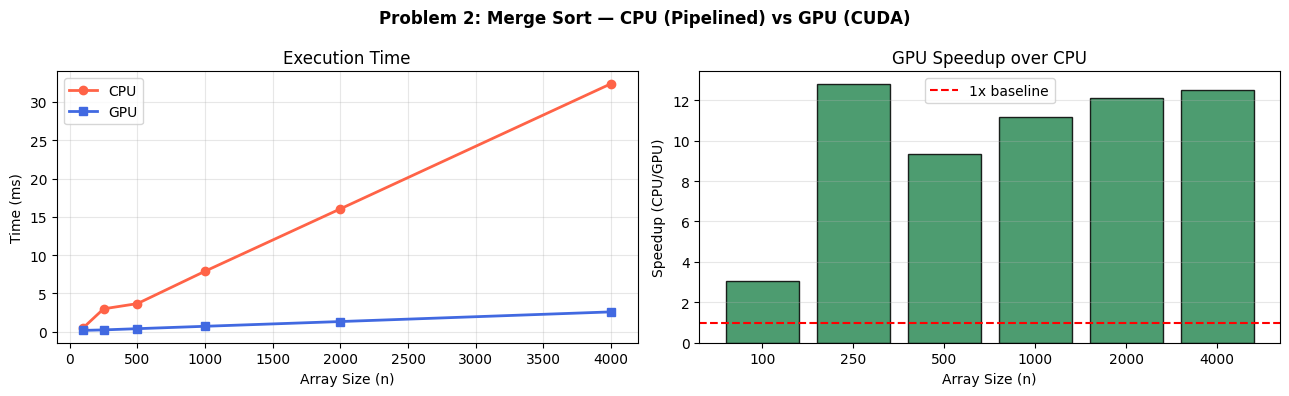

In [5]:
sizes = [100, 250, 500, 1000, 2000, 4000]
cpu_times, gpu_times = [], []

for sz in sizes:
    data = np.random.randint(0, 100000, sz).astype(np.int32)

    # CPU
    a = data.copy()
    t0 = time.perf_counter()
    merge_sort_cpu(a, 0, sz - 1)
    cpu_times.append((time.perf_counter() - t0) * 1000)

    # GPU (warm-up then measure)
    for _ in range(2):
        b   = data.copy()
        tmp = np.zeros(sz, dtype=np.int32)
        d_b   = cuda.mem_alloc(b.nbytes)
        d_tmp = cuda.mem_alloc(tmp.nbytes)
        cuda.memcpy_htod(d_b, b)
        cuda.memcpy_htod(d_tmp, tmp)
        s = cuda.Event(); e = cuda.Event()
        s.record()
        w = 1
        while w < sz:
            nm  = (sz + 2*w - 1) // (2*w)
            bs  = 128
            gs  = (nm + bs - 1) // bs
            merge_pass_fn(d_b, d_tmp, np.int32(sz), np.int32(w),
                          block=(bs,1,1), grid=(gs,1))
            w *= 2
        e.record(); e.synchronize()
        t_gpu = s.time_till(e)
        d_b.free(); d_tmp.free()
    gpu_times.append(t_gpu)

    print(f'  n={sz:>5} | CPU {cpu_times[-1]:8.4f} ms | GPU {gpu_times[-1]:8.4f} ms | Speedup {cpu_times[-1]/gpu_times[-1]:.2f}x')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Problem 2: Merge Sort — CPU (Pipelined) vs GPU (CUDA)', fontweight='bold')

axes[0].plot(sizes, cpu_times, 'o-', color='tomato',     label='CPU', linewidth=2)
axes[0].plot(sizes, gpu_times, 's-', color='royalblue',  label='GPU', linewidth=2)
axes[0].set_xlabel('Array Size (n)'); axes[0].set_ylabel('Time (ms)')
axes[0].set_title('Execution Time'); axes[0].legend(); axes[0].grid(alpha=0.3)

speedups = [c/g for c,g in zip(cpu_times, gpu_times)]
axes[1].bar([str(s) for s in sizes], speedups, color='seagreen', edgecolor='black', alpha=0.85)
axes[1].axhline(1, color='red', linestyle='--', label='1x baseline')
axes[1].set_xlabel('Array Size (n)'); axes[1].set_ylabel('Speedup (CPU/GPU)')
axes[1].set_title('GPU Speedup over CPU'); axes[1].legend(); axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('p2_mergesort.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Problem 3 — Vector Addition + Bandwidth Analysis
### 3.0 — Basic Vector Addition

In [6]:
vec_add_kernel = SourceModule("""
__global__ void vectorAdd(float *a, float *b, float *c, int n) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < n) c[i] = a[i] + b[i];
}
""")
vec_add = vec_add_kernel.get_function('vectorAdd')

N = 1 << 20   # 1M elements
h_a = np.random.rand(N).astype(np.float32)
h_b = np.random.rand(N).astype(np.float32)
h_c = np.zeros(N, dtype=np.float32)

d_a = cuda.mem_alloc(h_a.nbytes)
d_b = cuda.mem_alloc(h_b.nbytes)
d_c = cuda.mem_alloc(h_c.nbytes)
cuda.memcpy_htod(d_a, h_a)
cuda.memcpy_htod(d_b, h_b)

BLOCK = 256
GRID  = (N + BLOCK - 1) // BLOCK

vec_add(d_a, d_b, d_c, np.int32(N), block=(BLOCK,1,1), grid=(GRID,1))
cuda.memcpy_dtoh(h_c, d_c)

print(f'Vector Addition (N={N:,})')
print(f'Correct: {np.allclose(h_c, h_a + h_b)}')

Vector Addition (N=1,048,576)
Correct: True


### 3.1 — Static Global Variables (no cudaMalloc)

Device arrays are declared at compile time using `__device__` static arrays.
We use `cuda.module_from_file` / `get_global` to write to them from host instead of `cudaMalloc`.

In [7]:
N_STATIC = 1024   # fixed at compile time

static_kernel = SourceModule(f"""
#define N_STATIC {N_STATIC}

__device__ float d_a[N_STATIC];
__device__ float d_b[N_STATIC];
__device__ float d_c[N_STATIC];

__global__ void vectorAddStatic() {{
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < N_STATIC) d_c[i] = d_a[i] + d_b[i];
}}
""")

vec_add_static = static_kernel.get_function('vectorAddStatic')

h_a_s = np.random.rand(N_STATIC).astype(np.float32)
h_b_s = np.random.rand(N_STATIC).astype(np.float32)

# Copy to static device symbols via get_global
d_a_ptr, _ = static_kernel.get_global('d_a')
d_b_ptr, _ = static_kernel.get_global('d_b')
cuda.memcpy_htod(d_a_ptr, h_a_s)
cuda.memcpy_htod(d_b_ptr, h_b_s)

BLOCK_S = 128
GRID_S  = (N_STATIC + BLOCK_S - 1) // BLOCK_S
vec_add_static(block=(BLOCK_S, 1, 1), grid=(GRID_S, 1))

d_c_ptr, _ = static_kernel.get_global('d_c')
h_c_s = np.zeros(N_STATIC, dtype=np.float32)
cuda.memcpy_dtoh(h_c_s, d_c_ptr)

print(f'Static global var vector add (N={N_STATIC})')
print(f'Correct: {np.allclose(h_c_s, h_a_s + h_b_s)}')

Static global var vector add (N=1024)
Correct: True


### 3.2 — Kernel Timing

In [8]:
N = 1 << 20
h_a = np.random.rand(N).astype(np.float32)
h_b = np.random.rand(N).astype(np.float32)
h_c = np.zeros(N, dtype=np.float32)

d_a = cuda.mem_alloc(h_a.nbytes)
d_b = cuda.mem_alloc(h_b.nbytes)
d_c = cuda.mem_alloc(h_c.nbytes)
cuda.memcpy_htod(d_a, h_a)
cuda.memcpy_htod(d_b, h_b)

BLOCK = 256
GRID  = (N + BLOCK - 1) // BLOCK

start_ev = cuda.Event()
end_ev   = cuda.Event()

start_ev.record()
vec_add(d_a, d_b, d_c, np.int32(N), block=(BLOCK,1,1), grid=(GRID,1))
end_ev.record()
end_ev.synchronize()

kernel_time_ms = start_ev.time_till(end_ev)
print(f'Kernel execution time : {kernel_time_ms:.4f} ms')

cuda.memcpy_dtoh(h_c, d_c)

Kernel execution time : 0.1573 ms


### 3.3 — Theoretical Memory Bandwidth

In [9]:
dev  = cuda.Device(0)
attr = dev.get_attributes()

mem_clock_khz = attr[cuda.device_attribute.MEMORY_CLOCK_RATE]     # kHz
bus_width     = attr[cuda.device_attribute.GLOBAL_MEMORY_BUS_WIDTH]  # bits

# theoretical BW = memClockRate * busWidth * 2 (DDR)
# kHz * bits = kbits/s  →  / 8 = kB/s  →  / 1e6 = GB/s
theoretical_bw = (mem_clock_khz * bus_width * 2) / 8 / 1e6

print(f'Memory Clock Rate     : {mem_clock_khz:,} kHz  ({mem_clock_khz/1e6:.3f} GHz)')
print(f'Memory Bus Width      : {bus_width} bits')
print(f'Theoretical Bandwidth : {theoretical_bw:.2f} GB/s')

Memory Clock Rate     : 5,001,000 kHz  (5.001 GHz)
Memory Bus Width      : 256 bits
Theoretical Bandwidth : 320.06 GB/s


### 3.4 — Measured Memory Bandwidth

In [10]:
# vectorAdd reads 2 arrays and writes 1  →  3 * N * sizeof(float) bytes
R_bytes = 2 * N * np.dtype(np.float32).itemsize
W_bytes = 1 * N * np.dtype(np.float32).itemsize
total_bytes = R_bytes + W_bytes

kernel_time_s = kernel_time_ms / 1e3
measured_bw   = total_bytes / kernel_time_s / 1e9

print(f'N                     : {N:,} elements')
print(f'Bytes Read            : {R_bytes / 1e6:.1f} MB  (2 input arrays)')
print(f'Bytes Written         : {W_bytes / 1e6:.1f} MB  (1 output array)')
print(f'Total Bytes Moved     : {total_bytes / 1e6:.1f} MB')
print(f'Kernel Time           : {kernel_time_ms:.4f} ms')
print(f'Measured  Bandwidth   : {measured_bw:.2f} GB/s')
print(f'Theoretical Bandwidth : {theoretical_bw:.2f} GB/s')
print(f'Efficiency            : {100 * measured_bw / theoretical_bw:.1f}%')

d_a.free(); d_b.free(); d_c.free()

N                     : 1,048,576 elements
Bytes Read            : 8.4 MB  (2 input arrays)
Bytes Written         : 4.2 MB  (1 output array)
Total Bytes Moved     : 12.6 MB
Kernel Time           : 0.1573 ms
Measured  Bandwidth   : 79.99 GB/s
Theoretical Bandwidth : 320.06 GB/s
Efficiency            : 25.0%


### 3.4 — Bandwidth vs Array Size (Performance Plot)

  N=   65,536 | 0.036 ms | 21.81 GB/s
  N=  262,144 | 0.039 ms | 81.51 GB/s
  N=1,048,576 | 0.053 ms | 236.31 GB/s
  N=4,194,304 | 0.198 ms | 254.10 GB/s
  N=16,777,216 | 0.770 ms | 261.62 GB/s


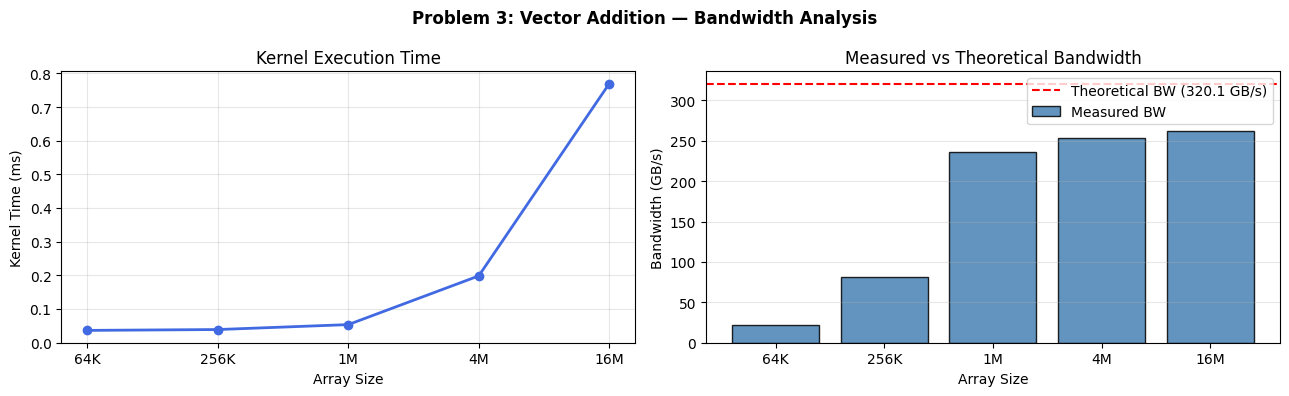

In [11]:
sizes_p3   = [1<<16, 1<<18, 1<<20, 1<<22, 1<<24]
meas_bws   = []
times_ms   = []

for sz in sizes_p3:
    a = np.random.rand(sz).astype(np.float32)
    b = np.random.rand(sz).astype(np.float32)
    c = np.zeros(sz, dtype=np.float32)
    da = cuda.mem_alloc(a.nbytes)
    db = cuda.mem_alloc(b.nbytes)
    dc = cuda.mem_alloc(c.nbytes)
    cuda.memcpy_htod(da, a); cuda.memcpy_htod(db, b)

    BLK = 256
    GRD = (sz + BLK - 1) // BLK

    # warm-up
    vec_add(da, db, dc, np.int32(sz), block=(BLK,1,1), grid=(GRD,1))

    s = cuda.Event(); e = cuda.Event()
    s.record()
    vec_add(da, db, dc, np.int32(sz), block=(BLK,1,1), grid=(GRD,1))
    e.record(); e.synchronize()
    t_ms = s.time_till(e)
    bw   = 3 * sz * 4 / (t_ms / 1e3) / 1e9

    times_ms.append(t_ms)
    meas_bws.append(bw)
    da.free(); db.free(); dc.free()
    print(f'  N={sz:>9,} | {t_ms:.3f} ms | {bw:.2f} GB/s')

labels = [f'{s//1024}K' if s < 1<<20 else f'{s//1048576}M' for s in sizes_p3]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Problem 3: Vector Addition — Bandwidth Analysis', fontweight='bold')

axes[0].plot(labels, times_ms, 'o-', color='royalblue', linewidth=2)
axes[0].set_xlabel('Array Size'); axes[0].set_ylabel('Kernel Time (ms)')
axes[0].set_title('Kernel Execution Time'); axes[0].grid(alpha=0.3)

axes[1].bar(labels, meas_bws, color='steelblue', edgecolor='black', alpha=0.85, label='Measured BW')
axes[1].axhline(theoretical_bw, color='red', linestyle='--', linewidth=1.5, label=f'Theoretical BW ({theoretical_bw:.1f} GB/s)')
axes[1].set_xlabel('Array Size'); axes[1].set_ylabel('Bandwidth (GB/s)')
axes[1].set_title('Measured vs Theoretical Bandwidth'); axes[1].legend(); axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('p3_bandwidth.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Summary

| Problem | Task | Status |
|---------|------|--------|
| 1a | Sum of N integers — iterative (Thread 0) | ✅ |
| 1b | Sum of N integers — formula (Thread 1) | ✅ |
| 2a | Pipelined CPU merge sort | ✅ |
| 2b | Parallel CUDA merge sort (bottom-up) | ✅ |
| 2c | Performance comparison + plots | ✅ |
| 3.0 | Basic vector addition kernel | ✅ |
| 3.1 | Static global device variables | ✅ |
| 3.2 | Kernel execution timing | ✅ |
| 3.3 | Theoretical memory bandwidth | ✅ |
| 3.4 | Measured bandwidth + comparison plot | ✅ |